# Coffee Bean Roast Level Classification - ML Model

This notebook loads processed images, extracts features, trains a Random Forest classifier, and saves the model for evaluation.

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support, roc_curve, auc, roc_auc_score, RocCurveDisplay, brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.model_selection import cross_val_score, learning_curve, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import joblib

# Custom functions
from coffee_utils import load_image, extract_features, FEATURE_NAMES

import warnings
warnings.filterwarnings('ignore')

### Paths

In [2]:
BASE_PATH = Path("coffee_data")
ROAST_LEVELS = ["Green", "Light", "Medium", "Dark"]
ORDER = ROAST_LEVELS  # Keep for label encoding
RANDOM_STATE = 42

### Load Images and Create Train/Test Split

In [3]:
# Build dataframe from roast-level folders
rows = []
for roast in ROAST_LEVELS:
    folder = BASE_PATH / roast
    if folder.exists():
        for f in sorted(folder.glob("*.png")):
            rows.append({"filepaths": str(folder / f.name), "labels": roast})
df = pd.DataFrame(rows)

# Stratified 80/20 train/test split (reproducible)
train_df, test_df = train_test_split(df, test_size = 0.2, stratify = df["labels"], random_state = RANDOM_STATE)
train_df = train_df.reset_index(drop = True)
test_df = test_df.reset_index(drop = True)

train_df["processed_path"] = train_df["filepaths"]  # Images processed in place
test_df["processed_path"] = test_df["filepaths"]

print(f"Total: {len(df)} images")
print(f"Train: {len(train_df)} images | Test: {len(test_df)} images")
print(f"Test set distribution: {test_df['labels'].value_counts().sort_index().to_dict()}")

Total: 1194 images
Train: 955 images | Test: 239 images
Test set distribution: {'Dark': 59, 'Green': 60, 'Light': 60, 'Medium': 60}


### Extract Features

In [4]:
def build_feature_matrix(df):
    X, y, paths = [], [], []
    for i in range(len(df)):
        row = df.iloc[i]
        img = load_image(row["processed_path"])
        feat = extract_features(img)
        X.append(feat)
        y.append(row["labels"])
        paths.append(row["processed_path"])
    return np.array(X), np.array(y), paths

X_train, y_train, train_paths = build_feature_matrix(train_df)
X_test, y_test, test_paths = build_feature_matrix(test_df)

# Encode labels (train from y_train; test from paths so confusion matrix and misclassification list stay in sync)
le = LabelEncoder()
le.fit(ORDER)
y_train_enc = le.transform(y_train)
test_actual = [Path(p).parent.name for p in test_paths]  # single source of truth for test labels
y_test_enc = np.array(le.transform(test_actual))

print(f"X_train: {X_train.shape} | y_train: {y_train_enc.shape}")
print(f"X_test: {X_test.shape} | y_test: {y_test_enc.shape}")

X_train: (955, 15) | y_train: (955,)
X_test: (239, 15) | y_test: (239,)


### Scale Features

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Build Random Forest Model

In [6]:
# Pipeline: scale then classify (scaling is fit per CV fold during search)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state = RANDOM_STATE)),
])

# Hyperparameter grid for random search
param_distributions = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

# RandomizedSearchCV: fit on unscaled X_train so pipeline handles scaling inside CV
search = RandomizedSearchCV(
    pipe,
    param_distributions,
    n_iter = 24,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1,
    random_state = RANDOM_STATE,
    verbose = 1,
)
search.fit(X_train, y_train_enc)

print("Best CV accuracy:", search.best_score_)
print("Best params:", search.best_params_)

# Extract best scaler and classifier for downstream cells (same interface as before)
scaler = search.best_estimator_.named_steps["scaler"]
rf = search.best_estimator_.named_steps["clf"]
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV accuracy: 0.9811518324607331
Best params: {'clf__n_estimators': 50, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 30}


### Tree Visualization

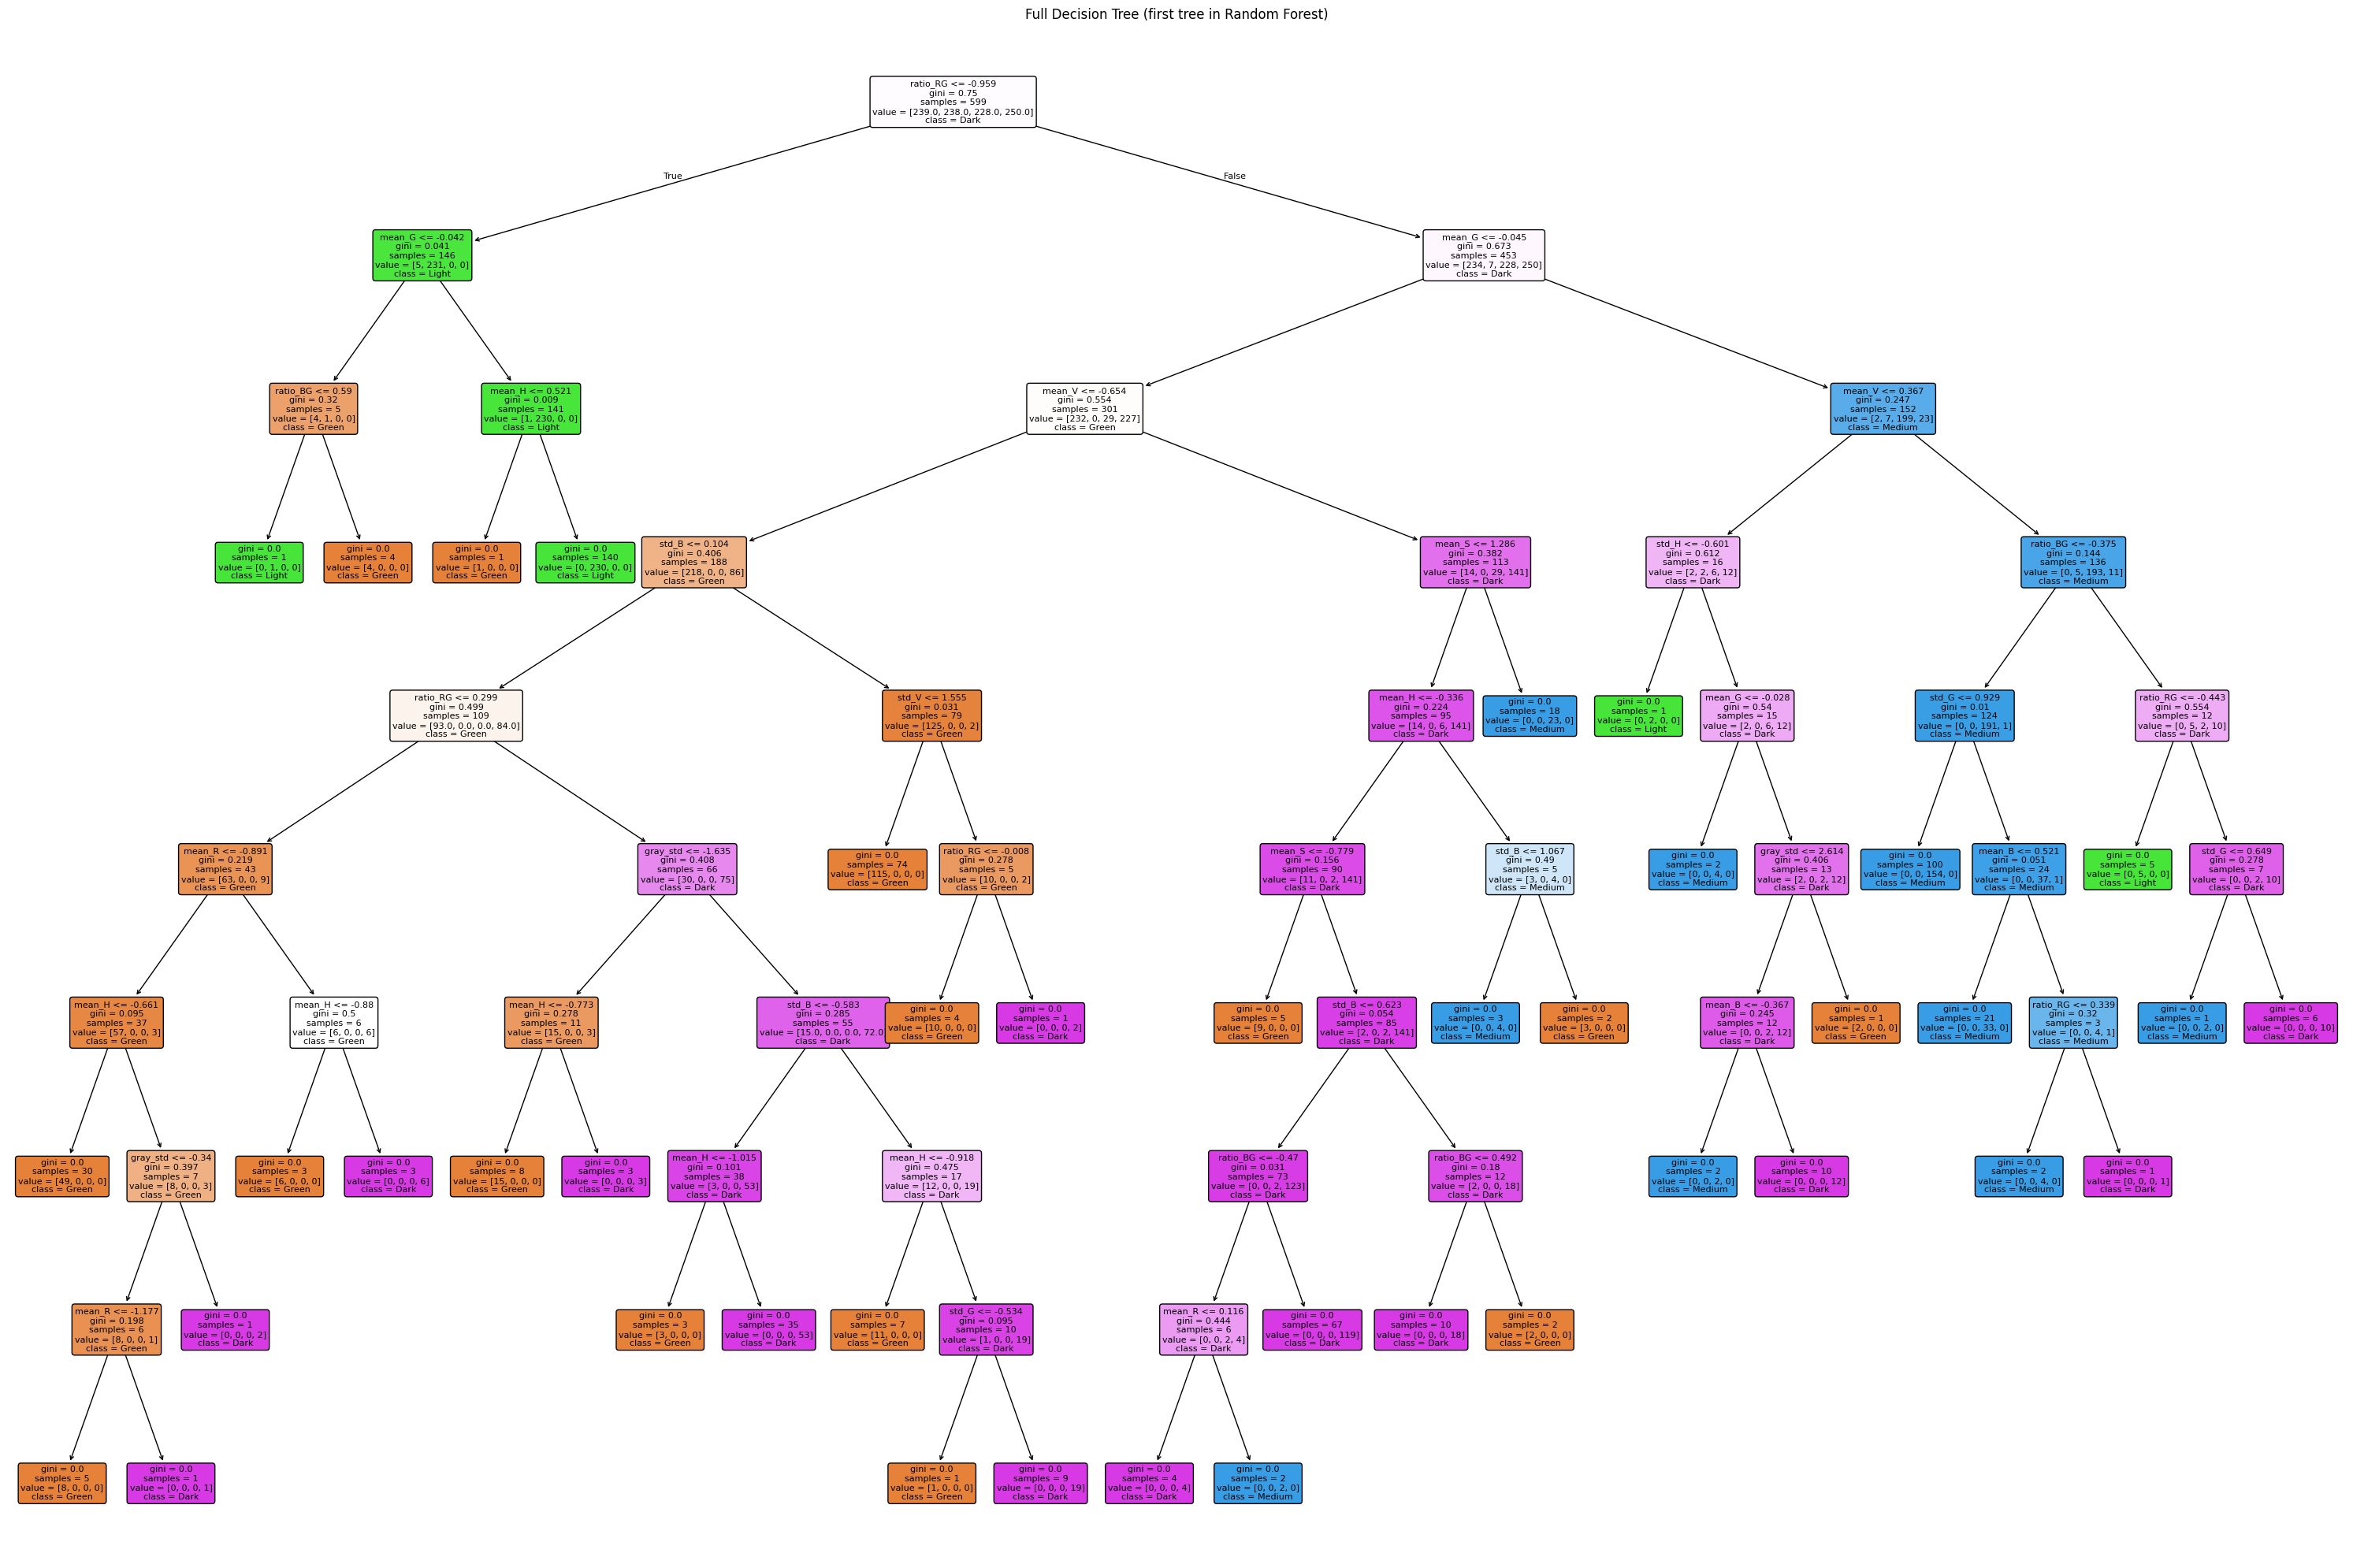

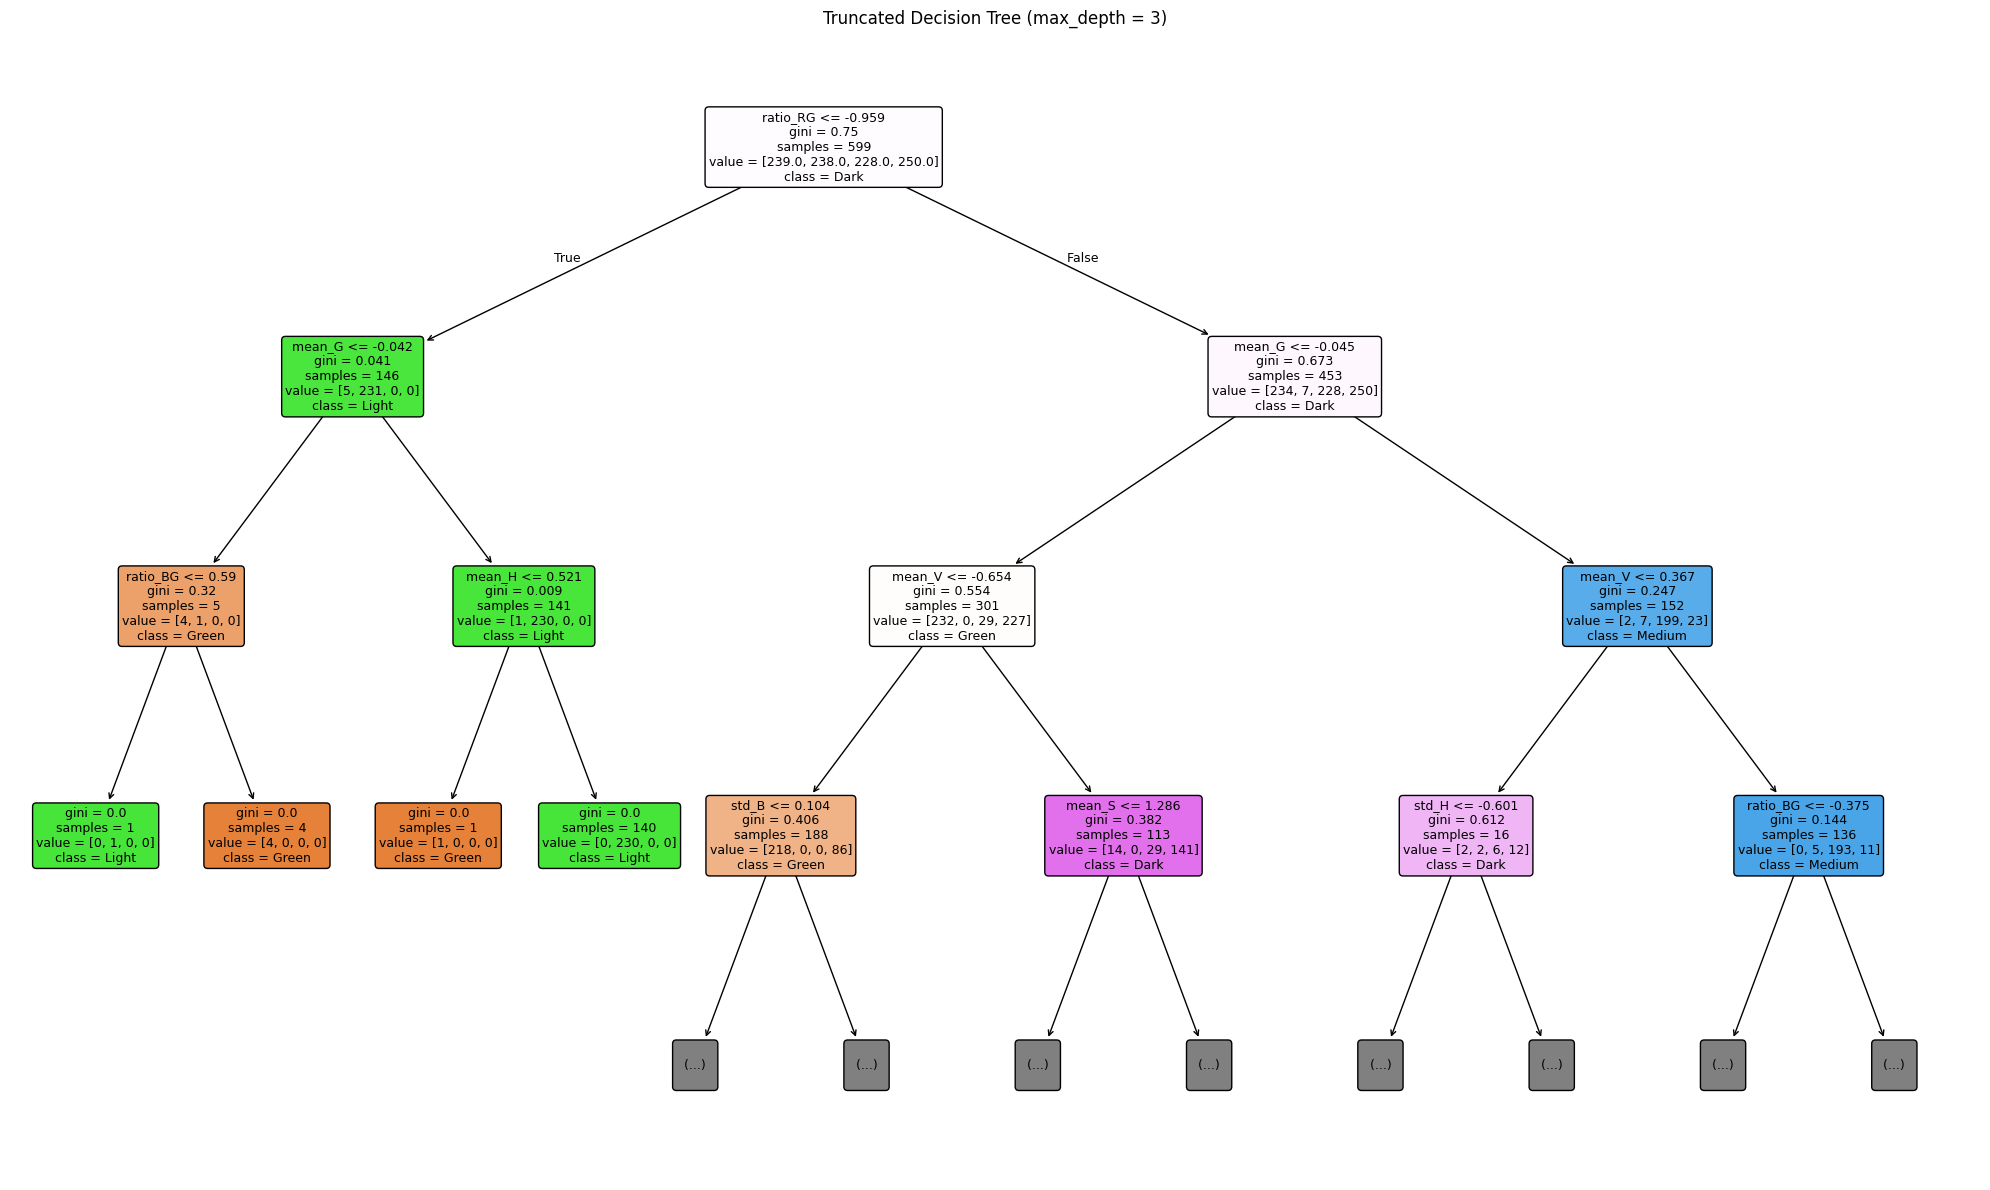

In [7]:
# Full tree: first tree in the forest (may be too large to read)
fig, ax = plt.subplots(figsize = (30, 20))
plot_tree(rf.estimators_[0], feature_names = FEATURE_NAMES, class_names = ORDER, filled = True, rounded = True, ax = ax, fontsize = 8)
ax.set_title("Full Decision Tree (first tree in Random Forest)")
plt.tight_layout()
plt.show()

# Truncated tree for readability
fig, ax = plt.subplots(figsize = (20, 12))
plot_tree(rf.estimators_[0], max_depth = 3, feature_names = FEATURE_NAMES, class_names = ORDER, filled = True, rounded = True, ax = ax, fontsize = 9)
ax.set_title("Truncated Decision Tree (max_depth = 3)")
plt.tight_layout()
plt.show()

## Metrics

### Confusion Matrix

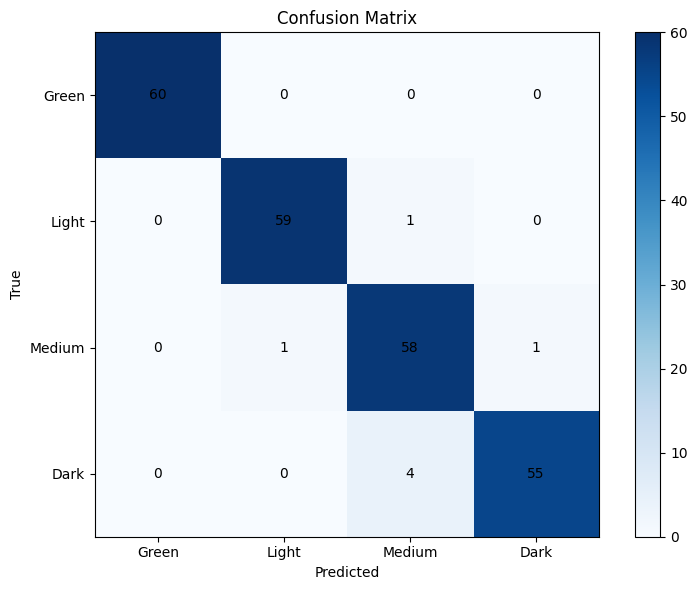

Confusion matrix (rows = true, cols = predicted):
        Green  Light  Medium  Dark
Green      60      0       0     0
Light       0     59       1     0
Medium      0      1      58     1
Dark        0      0       4    55


In [8]:
y_pred = rf.predict(X_test_scaled)

# Build confusion matrix from string labels (actual, pred) so display and list always match
counts = defaultdict(int)
for i in range(len(test_actual)):
    actual_str = test_actual[i]
    pred_str = le.inverse_transform([y_pred[i]])[0]
    counts[(actual_str, pred_str)] += 1

n_classes = len(ORDER)
cm = np.zeros((n_classes, n_classes), dtype = int)

for i, actual in enumerate(ORDER):
    for j, pred in enumerate(ORDER):
        cm[i, j] = counts[(actual, pred)]

test_actual_enc = np.array(le.transform(test_actual))  # for mis_idx and downstream

# Confusion matrix heatmap
plt.figure(figsize = (8, 6))
plt.imshow(cm, cmap = "Blues")
plt.colorbar()
plt.xticks(range(len(ORDER)), ORDER)
plt.yticks(range(len(ORDER)), ORDER)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        plt.text(j, i, str(cm[i, j]), ha = "center", va = "center")
plt.tight_layout()
plt.show()

# Tabular
print("Confusion matrix (rows = true, cols = predicted):")
cm_df = pd.DataFrame(cm, index = ORDER, columns = ORDER)
print(cm_df.to_string())

### Misclassified Images

Display images that were misclassified, with their actual and predicted labels, to help identify patterns or outliers.

Misclassified (actual -> predicted), should match confusion matrix:
  Dark -> Medium: 4
  Light -> Medium: 1
  Medium -> Dark: 1
  Medium -> Light: 1


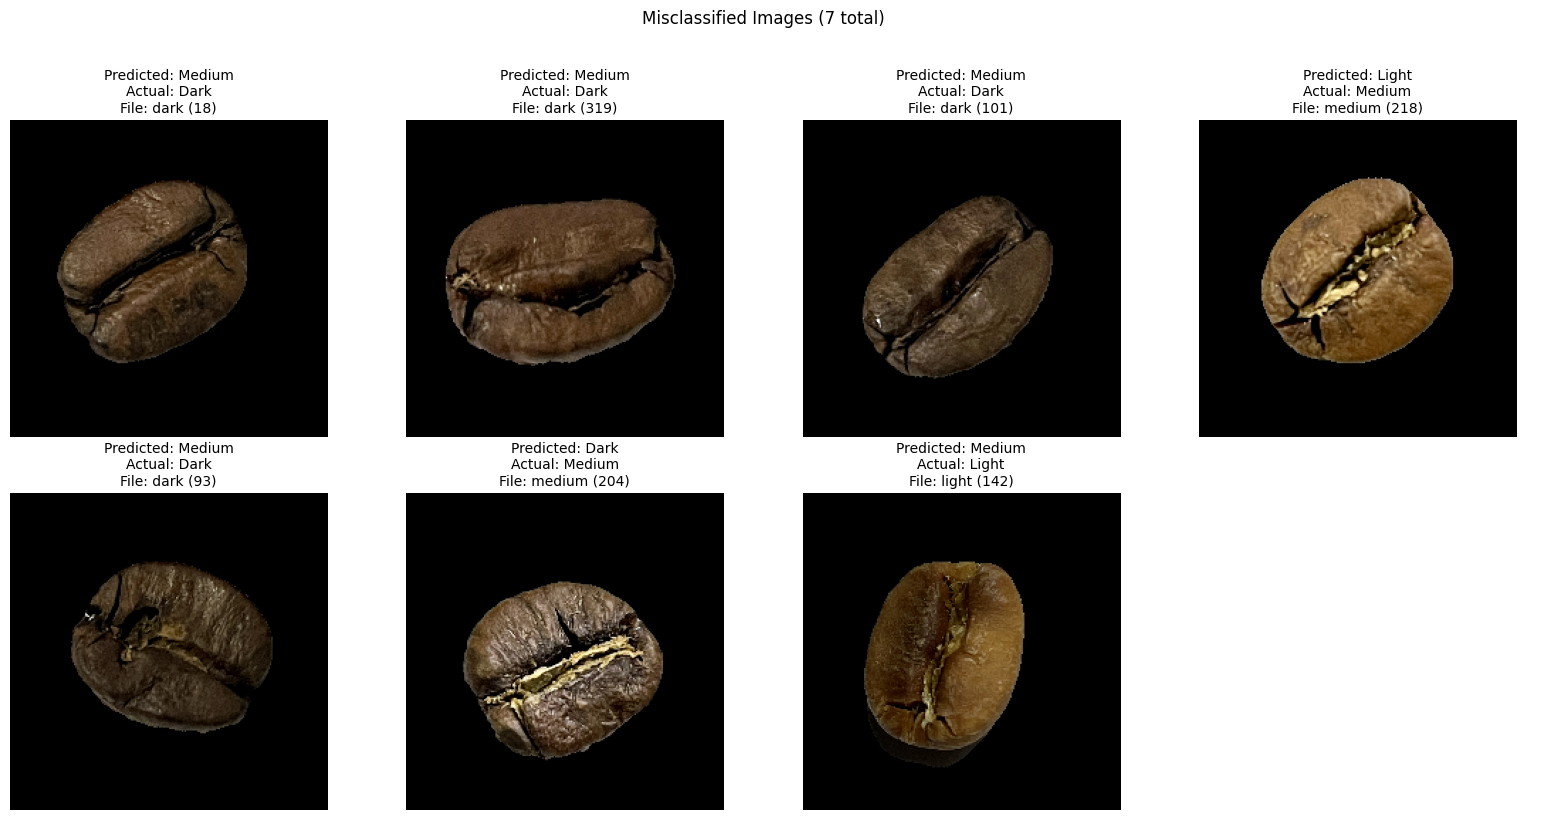

In [9]:
# Find misclassified samples (use same test_actual_enc as confusion matrix)
mis_idx = np.where(y_pred != test_actual_enc)[0]
n_mis = len(mis_idx)
if n_mis == 0:
    print("No misclassified images.")
else:
    # Use test_actual (same as y_test_enc source) so list matches confusion matrix
    mis_pairs = []
    for idx in mis_idx:
        actual = test_actual[idx]
        pred = le.inverse_transform([y_pred[idx]])[0]
        mis_pairs.append((actual, pred))
    mis_counts = Counter(mis_pairs)
    
    print("Misclassified (actual -> predicted), should match confusion matrix:")
    for (a, p), c in sorted(mis_counts.items()):
        print(f"  {a} -> {p}: {c}")
    n_cols = 4
    n_rows = int(np.ceil(n_mis / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize = (4 * n_cols, 4 * n_rows))
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(mis_idx):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        img_path = test_paths[idx]
        img = load_image(img_path)
        actual = test_actual[idx]
        pred = le.inverse_transform([y_pred[idx]])[0]
        ax.imshow(img)
        fname = Path(img_path).stem
        ax.set_title(f"Predicted: {pred}\nActual: {actual}\nFile: {fname}", fontsize = 10)
        ax.axis("off")
    
    # Hide unused subplots
    for i in range(n_mis, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].axis("off")
    
    plt.suptitle(f"Misclassified Images ({n_mis} total)", fontsize = 12, y = 1.02)
    plt.tight_layout()
    plt.show()

### Performance Metrics

In [10]:
# Performance metrics from confusion matrix
accuracy = accuracy_score(y_test_enc, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(y_test_enc, y_pred, labels = range(len(ORDER)))
report = classification_report(y_test_enc, y_pred, target_names = ORDER, digits = 4)

print(f"Overall accuracy: {accuracy:.4f}\n")
print("Per-class metrics:")
metrics_df = pd.DataFrame({
    "precision": precision,
    "recall": recall,
    "f1-score": f1,
    "support": support,
}, index = ORDER)

print(metrics_df.round(4).to_string())
print("\nClassification report (includes macro/weighted avg):")
print(report)

# Additional metrics from confusion matrix
# True positives per class (diagonal)
tp = np.diag(cm)
# False positives per class (column sum - diagonal)
fp = cm.sum(axis = 0) - tp
# False negatives per class (row sum - diagonal)
fn = cm.sum(axis = 1) - tp
print("\nPer-class: TP, FP, FN:")
extra_df = pd.DataFrame({"TP": tp, "FP": fp, "FN": fn}, index = ORDER)
print(extra_df.to_string())

Overall accuracy: 0.9707

Per-class metrics:
        precision  recall  f1-score  support
Green      0.9821  0.9322    0.9565       59
Light      1.0000  1.0000    1.0000       60
Medium     0.9833  0.9833    0.9833       60
Dark       0.9206  0.9667    0.9431       60

Classification report (includes macro/weighted avg):
              precision    recall  f1-score   support

       Green     0.9821    0.9322    0.9565        59
       Light     1.0000    1.0000    1.0000        60
      Medium     0.9833    0.9833    0.9833        60
        Dark     0.9206    0.9667    0.9431        60

    accuracy                         0.9707       239
   macro avg     0.9715    0.9706    0.9707       239
weighted avg     0.9715    0.9707    0.9708       239


Per-class: TP, FP, FN:
        TP  FP  FN
Green   60   0   0
Light   59   1   1
Medium  58   5   2
Dark    55   1   4


### Feature Importance

Feature importance (sorted):
 feature  importance
ratio_BG      0.1903
ratio_RG      0.1525
  mean_H      0.1383
  mean_V      0.1251
  mean_S      0.1178
  mean_G      0.0739
  mean_R      0.0712
  mean_B      0.0420
   std_H      0.0311
   std_S      0.0136
   std_R      0.0119
   std_B      0.0117
   std_V      0.0086
   std_G      0.0062
gray_std      0.0059


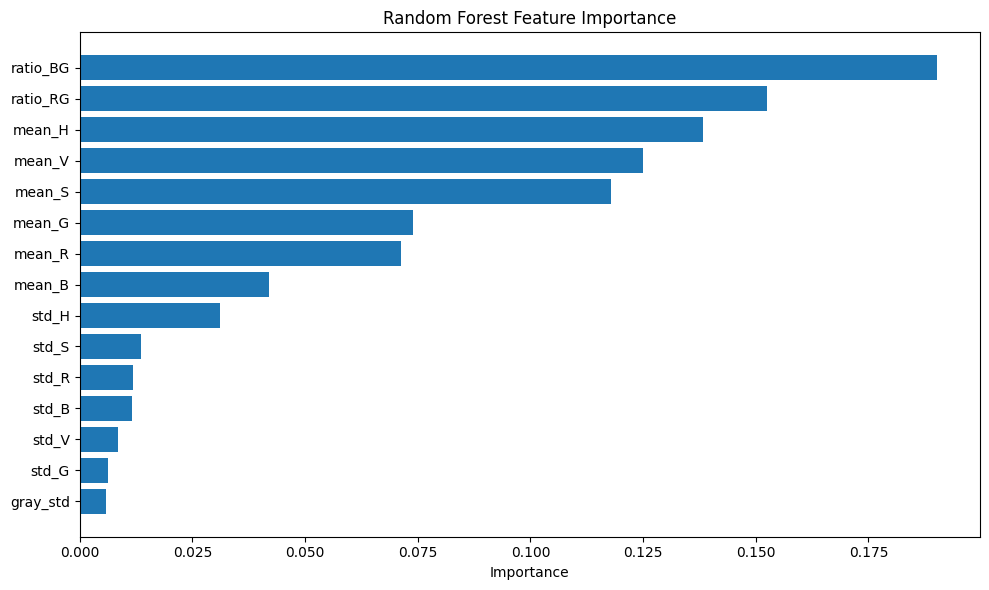

In [11]:
imp = rf.feature_importances_
order_idx = np.argsort(imp)[::-1]

# Table of feature importance (readable)
imp_df = pd.DataFrame({"feature": FEATURE_NAMES, "importance": imp}).sort_values("importance", ascending = False)
imp_df = imp_df.reset_index(drop = True)
print("Feature importance (sorted):")
print(imp_df.round(4).to_string(index = False))

# Bar chart
plt.figure(figsize = (10, 6))
plt.barh(range(len(FEATURE_NAMES)), imp[order_idx][::-1])
plt.yticks(range(len(FEATURE_NAMES)), [FEATURE_NAMES[i] for i in order_idx[::-1]])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

### Correlation Matrix

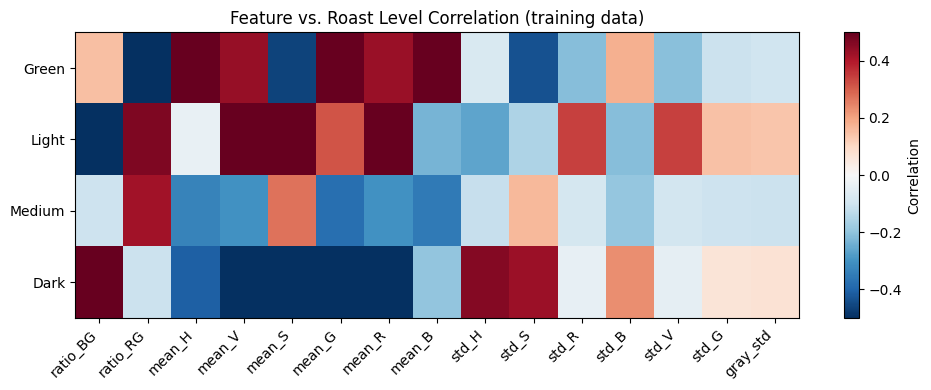

In [12]:
# Correlation: each feature vs. likelihood of each roast level (using all training data)
# Order features by importance (most to least) to match the feature importance plot
imp = rf.feature_importances_
order_idx = np.argsort(imp)[::-1]
feature_order = [FEATURE_NAMES[i] for i in order_idx]

df_corr = pd.DataFrame(X_train, columns = FEATURE_NAMES)
for roast in ORDER:
    df_corr[roast] = (y_train == roast).astype(float)
corr_matrix = df_corr.corr().loc[feature_order, ORDER]

fig, ax = plt.subplots(figsize = (10, 4))
im = ax.imshow(corr_matrix.values.T, cmap = 'RdBu_r', vmin = -0.5, vmax = 0.5, aspect = 'auto')
ax.set_xticks(range(len(feature_order)))
ax.set_xticklabels(feature_order, rotation = 45, ha = 'right')
ax.set_yticks(range(len(ORDER)))
ax.set_yticklabels(ORDER)
plt.colorbar(im, ax = ax, label = 'Correlation')
ax.set_title('Feature vs. Roast Level Correlation (training data)')
plt.tight_layout()
plt.show()

### ROC Curves (One-vs-Rest per Roast Level)

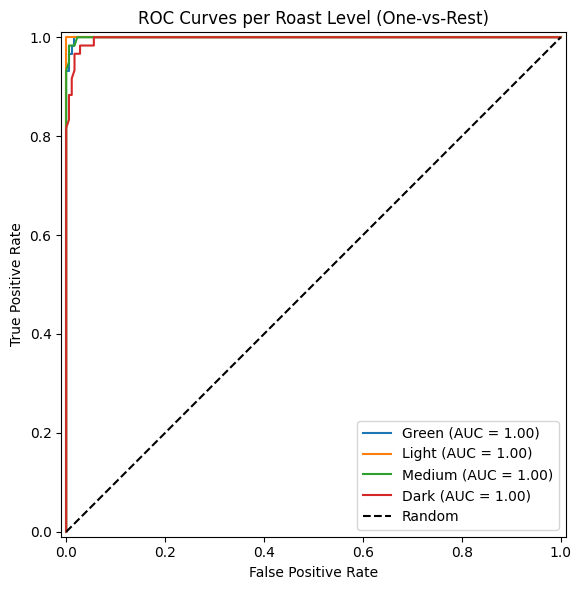

AUC per roast level (One-vs-Rest):
  Green: 0.9993
  Light: 1.0000
  Medium: 0.9994
  Dark: 0.9971
Macro AUC: 0.9990


In [13]:
# ROC curve per roast level (One-vs-Rest)
y_proba = rf.predict_proba(X_test_scaled)

aucs = []
fig, ax = plt.subplots(figsize = (8, 6))
for i, roast in enumerate(ORDER):
    y_binary = (y_test_enc == i).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, estimator_name = roast).plot(ax = ax)

ax.plot([0, 1], [0, 1], 'k--', label = 'Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves per Roast Level (One-vs-Rest)')
ax.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

# Print AUC per class and macro average
print("AUC per roast level (One-vs-Rest):")
for roast, a in zip(ORDER, aucs):
    print(f"  {roast}: {a:.4f}")
print(f"Macro AUC: {np.mean(aucs):.4f}")

### Learning Curve

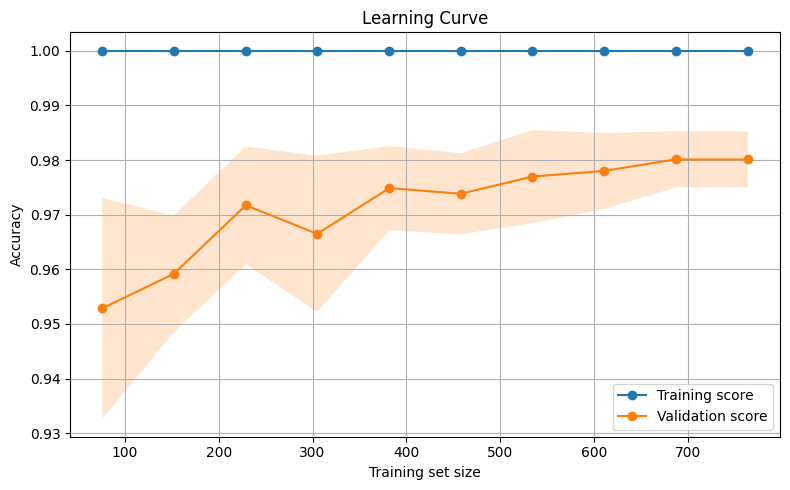

Learning curve summary:
  Train sizes: [76, 152, 229, 305, 382, 458, 534, 611, 687, 764]
  Train means: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  Validation scores: 
[[0.92670157 0.97905759 0.93193717 0.96335079 0.96335079]
 [0.95811518 0.97905759 0.95287958 0.95811518 0.94764398]
 [0.96335079 0.9895288  0.97382199 0.97382199 0.95811518]
 [0.95811518 0.9895288  0.97382199 0.96335079 0.94764398]
 [0.96335079 0.98429319 0.97905759 0.97905759 0.96858639]
 [0.97905759 0.98429319 0.97382199 0.96858639 0.96335079]
 [0.97905759 0.9895288  0.97382199 0.97905759 0.96335079]
 [0.96858639 0.9895288  0.97905759 0.97905759 0.97382199]
 [0.97382199 0.9895288  0.97905759 0.97905759 0.97905759]
 [0.97905759 0.9895288  0.97905759 0.97905759 0.97382199]]
  Validation means: [0.95287958 0.9591623  0.97172775 0.96649215 0.97486911 0.97382199
 0.97696335 0.97801047 0.98010471 0.98010471]
  Validation score at full data: 0.9801 (+/- 0.0051)


In [14]:
# Learning curve: performance vs. training set size
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators = 100, random_state = 42)),
])
train_sizes, train_scores, val_scores = learning_curve(
    pipe, X_train, y_train_enc, cv = 5, n_jobs = -1,
    train_sizes = np.linspace(0.1, 1.0, 10),
)
train_mean = train_scores.mean(axis = 1)
train_std = train_scores.std(axis = 1)
val_mean = val_scores.mean(axis = 1)
val_std = val_scores.std(axis = 1)

plt.figure(figsize = (8, 5))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha = 0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha = 0.2)
plt.plot(train_sizes, train_mean, "o-", label = "Training score")
plt.plot(train_sizes, val_mean, "o-", label = "Validation score")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend(loc = "lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print learning curve summary
print("Learning curve summary:")
print(f"  Train sizes: {train_sizes.astype(int).tolist()}")
print(f"  Train means: {train_mean}")
print(f"  Validation scores: \n{val_scores}")
print(f"  Validation means: {val_mean}")
print(f"  Validation score at full data: {val_mean[-1]:.4f} (+/- {val_std[-1]:.4f})")

## Save Model for Evaluation

Save the trained model, scaler, and label encoder for use in the evaluation notebook.

In [15]:
# Cross-validation: 5-fold on full training pipeline (scale + fit)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators = 100, random_state = 42)),
])
cv_scores = cross_val_score(pipe, X_train, y_train_enc, cv = 5, scoring = "accuracy")

print("5-fold cross-validation accuracy scores:")
print(f"  Fold scores: {cv_scores}")
print(f"  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

5-fold cross-validation accuracy scores:
  Fold scores: [0.97905759 0.9895288  0.97905759 0.97905759 0.97382199]
  Mean: 0.9801 (+/- 0.0103)


In [16]:
joblib.dump(rf, "coffee_rf_model.joblib")
joblib.dump(scaler, "coffee_scaler.joblib")
joblib.dump({"le": le, "feature_names": FEATURE_NAMES, "order": ORDER}, "coffee_metadata.joblib")

print("Saved: coffee_rf_model.joblib, coffee_scaler.joblib, coffee_metadata.joblib")

Saved: coffee_rf_model.joblib, coffee_scaler.joblib, coffee_metadata.joblib


## Summary of Results and Model Performance

This summary is based on the **test set** from the stratified 80/20 split on the deduplicated dataset (1,194 unique images; 239 test samples). All metrics and figures above reflect this split.

---

**Overall Performance**

The model achieves **high overall accuracy** on the test set (see the printed metrics above).

- **Confusion matrix:** Rows = true label, columns = predicted. Strong diagonal dominance: **Green** is classified perfectly; **Light**, **Medium**, and **Dark** each have a small number of confusions with adjacent roast levels.

- **Per-class metrics:** Precision, recall, and F1 (in the classification report above) are high across all four classes—Light often at or near 1.0, others in the mid-to-high 0.90s depending on the run.

---

**Misclassification Patterns**

The **Misclassified Images** grid above shows every test sample predicted incorrectly (7 total in the run illustrated).

- **Dark -> Medium (4):** Dominant error. Dark-roast beans predicted as medium; consistent with overlap in color and surface appearance between darker medium and lighter dark roasts.

- **Medium -> Light (1), Medium -> Dark (1), Light -> Medium (1):** Remaining errors all between adjacent roast levels.

Adjacent roast levels are the main source of confusion, as expected from the continuous nature of roast degree. The list of (actual -> predicted) counts matches the off-diagonal entries of the confusion matrix.

---

**Features and Correlation (Training Data)**

The **Feature vs. Roast Level Correlation** heatmap shows which features separate the classes:

- **Color ratios (ratio_BG, ratio_RG):** Strongly negative with **Green**, strongly positive with **Dark**. Strong discriminators between green/unroasted and dark beans.

- **Mean color components (mean_R, mean_G, mean_B, mean_H, mean_S, mean_V):** Decrease systematically from Green to Dark, matching the darkening of beans with roast.

- **Standard deviations (std_H, std_S, std_R, std_G, std_B, gray_std):** std_H and std_S more positive for **Dark** (more hue/saturation variation); other std and gray_std help separate **Green** and **Light**. The **feature importance** plot above shows which of these the Random Forest uses most.

---

**Learning Curve**

Training accuracy reaches **1.0**; validation accuracy rises to roughly **0.97-0.98**.

- **Overfitting:** The gap between training and validation indicates the model fits the training set very well but generalizes slightly less to unseen data.

- **Validation performance** is still strong; the curve suggests more training data could help generalization further.

---

**Results**

- **Performance:** The Random Forest with hand-crafted color and texture features performs well for roast level classification; most errors occur at boundaries between adjacent roasts (especially Dark/Medium and Medium/Light).

- **Drivers:** Color ratios and mean channel values are the main drivers; standard-deviation and texture (gray_std) features add useful signal.


## Baseline Model for Comparison: Linear Regression

Let's briefly compare the Random Forest against a simple **linear regression** baseline to prove that the RF model is warranted for this project. 

For linear regression, roast level is treated as ordinal (Green = 0, Light = 1, Medium = 2, Dark = 3). The model learns a linear relationship between the scaled features and this numeric outcome. Predictions are rounded to the nearest integer and clipped to [0, 3], then mapped back to class labels. This baseline assumes linear boundaries.


In [17]:
# Train baseline: linear regression on encoded labels (0, 1, 2, 3)
baseline = LinearRegression().fit(X_train_scaled, y_train_enc)
y_baseline_cont = baseline.predict(X_test_scaled)
y_baseline_enc = np.clip(np.round(y_baseline_cont).astype(int), 0, len(ORDER) - 1)

# Build confusion matrix from string labels (same as RF) for consistent comparison
baseline_pred_labels = le.inverse_transform(y_baseline_enc)
counts_baseline = defaultdict(int)

for i in range(len(test_actual)):
    actual_str = test_actual[i]
    pred_str = baseline_pred_labels[i]
    counts_baseline[(actual_str, pred_str)] += 1

cm_baseline = np.zeros((len(ORDER), len(ORDER)), dtype = int)

for i, actual in enumerate(ORDER):
    for j, pred in enumerate(ORDER):
        cm_baseline[i, j] = counts_baseline[(actual, pred)]

accuracy_baseline = (y_baseline_enc == test_actual_enc).mean()
accuracy_rf = (y_pred == test_actual_enc).mean()

print("Baseline (Linear Regression) confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm_baseline, index = ORDER, columns = ORDER).to_string())

print("\nAccuracy comparison:")
print(f"  Baseline (linear regression): {accuracy_baseline:.4f}")
print(f"  Random Forest:                {accuracy_rf:.4f}")
print(f"  RF outperforms baseline by    {(accuracy_rf - accuracy_baseline):.4f} ({(accuracy_rf - accuracy_baseline):.1%})")

Baseline (Linear Regression) confusion matrix (rows = true, cols = predicted):
        Green  Light  Medium  Dark
Green      51      6       0     3
Light       6     33      20     1
Medium      0     38      22     0
Dark       24      3       0    32

Accuracy comparison:
  Baseline (linear regression): 0.5774
  Random Forest:                0.9707
  RF outperforms baseline by    0.3933 (39.3%)


Evident in the results, a simple linear regression model performs poorly, with about 58% overall accuracy. It tends to misclassify medium- and dark-roast beans the most. The RF model has about 97% accuracy, about 39% more than simple linear regression. This drastic difference in accuracy justifies using the RF model for this project.